In [57]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunNoG"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Computing $n_\nu$

In [62]:
# Approximation to circular orbits for testing
_, _, earth_vels = SimPlot.SunEarthGC_frame_coords_circular(2024)
# earth_vels *= (Params.km/Params.s)/(Params.kpc/Params.s)

print(jnp.linalg.norm(earth_vels[::50], axis=-1))

[280.93340579 272.3604925  249.69115343 227.26260064 222.54399856
 239.69566689 264.42480972 279.74537053]


#### Explanation of Fermi_Dirac_boosted function.

In the CNB rest frame (let's call it S), the Fermi-Dirac distribution is isotropic:

$f(E) = \frac{1}{e^{E/T} + 1}$
where E is the neutrino energy and T is the CNB temperature.

Under a Lorentz boost to frame S' (Earth's frame) moving with velocity β = v/c relative to S, the energy transforms as:

$E' = \gamma E(1 - \beta \cdot \hat{p})$
where γ = 1/√(1-β²) is the Lorentz factor and $\hat{p}$ is the unit vector in the direction of the neutrino's momentum.

The temperature effectively transforms the same way due to the relativistic Doppler effect. We can write:

$\frac{E'}{T'} = \frac{E}{T}$
where T' is the effective temperature in the boosted frame.

This means:

$T' = T/[\gamma(1 - \beta \cdot \hat{p})]$
This is exactly what we compute as doppler_factor in the code.

Therefore, in the boosted frame, the distribution becomes:

$f(E') = \frac{1}{e^{E'/T'} + 1} = \frac{1}{e^{E\gamma(1 - \beta \cdot \hat{p})/T} + 1}$
This accounts for the fact that neutrinos coming head-on (β · p̂ ≈ -1) appear blueshifted (higher effective temperature), while those from behind (β · p̂ ≈ 1) appear redshifted (lower effective temperature).
The code implements this by:

Computing p̂ from the input momentum
Calculating the Doppler factor γ(1 - β · p̂)
Applying this factor to modify the temperature in the Fermi-Dirac distribution

This is why we see an anisotropic distribution in Earth's frame, even though the distribution is isotropic in the CNB frame.

In [76]:
def Fermi_Dirac_boosted(p_vec, v_boost, args):

    c_unit = args.c#/(args.km/args.s)  # c in our velocity units

    # Get direction of momentum
    p_direction = p_vec / jnp.linalg.norm(p_vec, axis=-1, keepdims=True)
    
    # Compute Doppler factor
    gamma = 1/jnp.sqrt(1 - jnp.sum(v_boost**2)/c_unit**2)
    doppler_factor = gamma * (1 - jnp.sum(v_boost*p_direction, axis=-1)/c_unit)

    # Apply Doppler factor to temperature
    T_effective = args.T_CNB / doppler_factor

    p_mag = jnp.linalg.norm(p_vec, axis=-1)

    # print(doppler_factor)
    # print(doppler_factor.shape)
    # print(p_mag.shape)
    # both (1, 5, 768, 1000)

    return 1/(jnp.exp(p_mag/T_effective) + 1)


def compute_nu_dens_days(days_steps, args):

    # List to store quantities for each day
    days_nrs_l = []
    n_nu_days_l = []

    # Get Earth velocities w.r.t. the GC, since DM sims are in that frame
    # note: This includes ("inherited") solar system motion

    # Using finite differences to compute speed (less accurate)
    # _, _, earth_vels = SimPlot.SunEarthGC_frame_coords(2024)

    # Using specific astropy functionality for speed (more accurate)
    # _, _, earth_vels = SimPlot.SunEarthGC_frame_coords_posvel(2024)
    # earth_vels *= (args.km/args.s)/(args.kpc/args.s)

    # Approximation to circular orbits for testing
    _, _, earth_vels = SimPlot.SunEarthGC_frame_coords_circular(2024)
    earth_vels *= (args.km/args.s)/(args.kpc/args.s)
    

    for day in range(0, 365, days_steps):

        # Load velocities for current day
        file_path = f"{sim_folder}/vectors_day{day+1}.npy"

        if os.path.exists(file_path):

            print(f"Day {day+1}/365")
            days_nrs_l.append(day+1)

            # (insert halo dimension at beginning to synchronize)
            day_vels = jnp.load(file_path)[..., 3:][None, ...]
            
            # Velocities from simulation frame to Earth frame
            # day_vels = SimUtil.CNB_to_Earth_frame_trafo(
            #     day_vels,
            #     earth_vels[day])

            # Sorted momenta arrays
            # _, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4(
            #     day_vels, nu_m_picks, 
            #     merge_last_axes=False, args=Params())
            # PSDs_days = Physics.Fermi_Dirac(p_z4_days, Params())
            
            _, p_vec_z0_days, p_vec_z4_days, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4_vec(
                day_vels, nu_m_picks, merge_last_axes=False, args=Params())
            
            PSDs_days = Fermi_Dirac_boosted(
                p_vec_z4_days, earth_vels[day]*(args.kpc/args.s), Params())

            # note: integration over individual pixels
            n_raw = trap(p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)
            pix_sr = 4*args.Pi/simdata.Npix
            n_cm3 = pix_sr*args.g_nu/((2*args.Pi)**3)*n_raw/args.cm**-3
            n_cm3_pix = jnp.array(n_cm3)
            n_tot = jnp.sum(n_cm3_pix, axis=-1)
            n_nu_days_l.append(n_tot)

    return jnp.array(days_nrs_l), jnp.array(n_nu_days_l)


days_nrs, n_nu_days = compute_nu_dens_days(days_steps=12, args=Params())

nu_base_name = "n_nu_days_circular_Earth_frame_dipoleFD"
jnp.save(f"{sim_folder}/{nu_base_name}.npy", n_nu_days)

nrs_base_name = "days_nrs_circular_Earth_frame_dipoleFD"
jnp.save(f"{sim_folder}/{nrs_base_name}.npy", days_nrs)

Day 1/365
Day 13/365
Day 25/365
Day 37/365
Day 49/365
Day 61/365
Day 73/365
Day 85/365
Day 97/365
Day 109/365
Day 121/365
Day 133/365
Day 145/365
Day 157/365
Day 169/365
Day 181/365
Day 193/365
Day 205/365
Day 217/365
Day 229/365
Day 241/365
Day 253/365
Day 265/365
Day 277/365
Day 289/365
Day 301/365
Day 313/365
Day 325/365
Day 337/365
Day 349/365
Day 361/365


## Computing and plotting annual modulations

n_nu_days shape: (31, 1, 5)


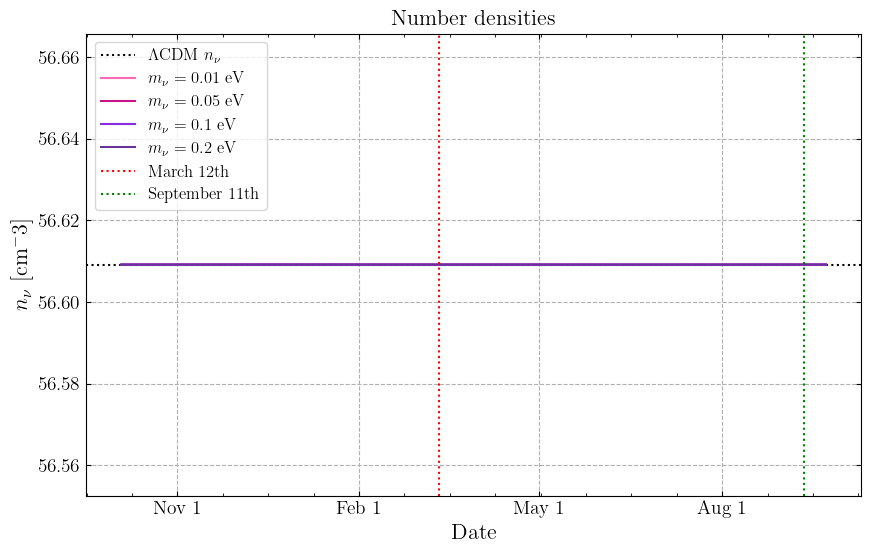

In [ ]:
def modulation_band(
        nu_dens_days, simulated_days, nu_m_picks, 
        start_date_str='09-11', mode='modulation', pdf_suffix=""):
    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Shift days to start from the specified date
    shifted_days = (simulated_days - start_day_of_year) % 365 + 1
    sorted_indices = jnp.argsort(shifted_days)
    shifted_days = shifted_days[sorted_indices]

    # Adjust vertical lines for March 12th and September 11th
    march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1

    violet_colors = [
        # "lightpink",
        "hotpink", 
        "mediumvioletred", 
        "blueviolet",
        "rebeccapurple",
    ]

    for m_idx, (m_val, color) in enumerate(zip(nu_m_picks, violet_colors)):
        
        if FD_bool:
            nu_dens_m = nu_dens_days[:, m_idx]  # (days,)
        else:
            nu_dens_m = nu_dens_days[:, :, m_idx]  # (days, halos)

        #? Since we started from Dec 31st to Jan 1st, we should flip array?
        nu_dens_m = jnp.flip(nu_dens_m, axis=0)

        # Compute fractional modulation for each halo
        nu_min = jnp.min(nu_dens_m, axis=0)
        mod = (nu_dens_m - nu_min) / (nu_dens_m + nu_min) * 100

        if mode == 'densities':
            mod = nu_dens_m
            plt.title("Number densities")
            plt.ylabel(r'$n_\nu$ [${\rm cm}^-3$]')

            if m_idx == 0:
                plt.axhline(y=Params.N0_cm3, color='k', linestyle=":", label=r"$\Lambda$CDM $n_\nu$")
        else:
            plt.title("Annual modulation")
            plt.ylabel(r'Modulation ($\%$)')

        # Sort modulation values for each day
        # mod_sorted = jnp.sort(mod, axis=1)

        # Compute median and 1-sigma band
        median = jnp.median(mod, axis=-1)
        lower = jnp.percentile(mod, 16, axis=-1)
        upper = jnp.percentile(mod, 84, axis=-1)

        # Apply sorting to match shifted_days
        median = median[sorted_indices]
        lower = lower[sorted_indices]
        upper = upper[sorted_indices]

        # Plot median and 1-sigma band
        ax.plot(shifted_days, median, '-', color=color, label=fr"$m_\nu = {m_val}$ eV")
        # ax.fill_between(shifted_days, lower, upper, color=color, alpha=0.3)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']

    plt.xticks(tick_days, tick_labels)

    # Set axis limits and labels
    # plt.ylim(0, 5)
    # plt.ylim(0.999*Params.N0_cm3, 1.001*Params.N0_cm3)
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, which="major", linestyle="dashed")

    plt.axvline(x=march_12, color='r', linestyle=':', label='March 12th')
    plt.axvline(x=sept_11, color='g', linestyle=':', label='September 11th')

    plt.legend(prop={"size":12})

    pdf_name = f"modulation{pdf_suffix}"
    plt.savefig(f"{fig_folder}/{pdf_name}.pdf", bbox_inches="tight")

    plt.show()
    plt.close()


# suffix = ""
# suffix = "_circular"
# suffix = "_circular_Earth_frame"
# suffix = "_circular_Earth_frame_dipoleFD"
suffix = "_circular_Earth_frame_dipoleFD"

nu_base_name = f"n_nu_days{suffix}"
n_nu_days = jnp.load(f"{sim_folder}/{nu_base_name}.npy")
print(f"n_nu_days shape: {n_nu_days.shape}")

nrs_base_name = f"days_nrs{suffix}"
days_nrs = jnp.load(f"{sim_folder}/{nrs_base_name}.npy")

"""
# Call the modulation function with the full n_nu_days array
modulation_band(
    nu_dens_days=n_nu_days, 
    simulated_days=days_nrs,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities',
    pdf_suffix=f"{suffix}_densities",
    # pdf_suffix=f"{suffix}_modulation",
)
"""